In [513]:
import numpy as np
from scipy.sparse import diags,kron,identity,csr_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
 
def lap1d(n, h):

    A = diags([-1, 2, -1], [-1, 0, 1], shape=(n, n),format='csr')

    A[0, - 1] = -1
    A[- 1, 0] = -1

    return A / (h ** 2)

def lap2d(n,h):
    A = kron(lap1d(n,h),identity(n)) + kron(identity(n),lap1d(n,h))
    return A

def adv2d(A1,A2,n,h):
    u_p = diags([1],[1],shape=(n,n),format='csr') 
    u_p[n-1,0] = 1

    u_m = diags([-1],[-1],shape=(n,n),format='csr') 
    u_m[0,n-1] = -1
    
    A1_p = kron(identity(n),u_p)
    A1_m = kron(identity(n),u_m)

    A2_p = kron(u_p,identity(n))
    A2_m = kron(u_m,identity(n))

    a1_vect_p = np.reshape(A1,-1)
    a1_vect_m = np.reshape(np.roll(A1,-1,axis=1),-1)

    a2_vect_p = np.reshape(A2,-1)

    M1_p = A1_p@diags(a1_vect_p)
    M1_m = A1_m@diags(a1_vect_m)
    
    M2_p = diags(a2_vect_p)@A2_p
    M2_m = A2_m@diags(a2_vect_p)

    M1 = M1_p + M1_m
    M2 = M2_p + M2_m

    return (M2+M1)/(2*h)

def grad(p,h):
    pi = np.vstack([p,p[0,:]]) - np.vstack([p[-1,:],p])
    pj = np.hstack([p,p[:,[0]]]) - np.hstack([p[:,[-1]],p])

    return pi/h,pj/h

def div(u,v,h):
    du = u[1:,:]-u[:-1,:]
    dv = v[:,1:]-v[:,:-1]
    
    return (du+dv)/h


A = np.random.randint(1, 9, size=(4, 4))
B = np.random.randint(1, 9, size=(4, 4))
print(A)
print(B)
print(adv2d(A,B,4,0.5).toarray())

[[6 4 2 3]
 [1 5 4 8]
 [2 8 2 5]
 [6 8 8 8]]
[[3 1 2 4]
 [4 6 8 6]
 [4 2 7 3]
 [1 3 8 1]]
[[ 0.  4.  0. -6.  3.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  0.]
 [-4.  0.  2.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0. -3.  0.  0.]
 [ 0. -2.  0.  3.  0.  0.  2.  0.  0.  0.  0.  0.  0.  0. -8.  0.]
 [ 6.  0. -3.  0.  0.  0.  0.  4.  0.  0.  0.  0.  0.  0.  0. -1.]
 [-3.  0.  0.  0.  0.  5.  0. -1.  4.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0. -5.  0.  4.  0.  0.  6.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -2.  0.  0. -4.  0.  8.  0.  0.  8.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -4.  1.  0. -8.  0.  0.  0.  0.  6.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -4.  0.  0.  0.  0.  8.  0. -2.  4.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -6.  0.  0. -8.  0.  2.  0.  0.  2.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -8.  0.  0. -2.  0.  5.  0.  0.  7.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -6.  2.  0. -5.  0.  0.  0.  0.  3.]
 [ 1.  0.  0.  0.  0.  0.  0.  0. -4.  0.  0.  0.  0.  8.  0. -6.]
 [ 0.  3.  0.  0.  0.  0.  0.  0.  0. -

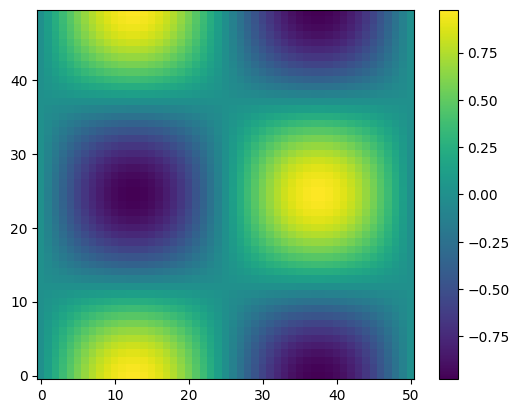

In [514]:
nu = 10e-3

def u(x,y,t):
    return (np.sin(x)*np.cos(y)*np.exp(-2*nu*t))

def v(x,y,t):
    return(-np.cos(x)*np.sin(y)*np.exp(-2*nu*t))

def p(x,y,t):
    return((np.cos(2*x)+np.cos(2*y))*np.exp(-4*nu*t)/4)

L = 2*np.pi
N = 50
h=L/N
x = np.linspace(0,L,N+1)
y = np.linspace(0,L,N+1)
xm = 0.5*(x[1:] + x[:-1])
ym = xm

XXu, YYu = np.meshgrid(x,ym,indexing='ij')
XXv, YYv = np.meshgrid(ym,x,indexing='ij')
XXp, YYp = np.meshgrid(xm,ym,indexing='ij')

u_test = u(XXu,YYu,1)
v_test = v(XXv,YYv,1)
#print('u',np.shape(u_test))
#print('v',np.shape(v_test))
#print(np.shape(div(u_test,v_test,1)))
#print(div(u_test,v_test,1))


plt.imshow(u_test.T,origin='lower')
plt.colorbar()

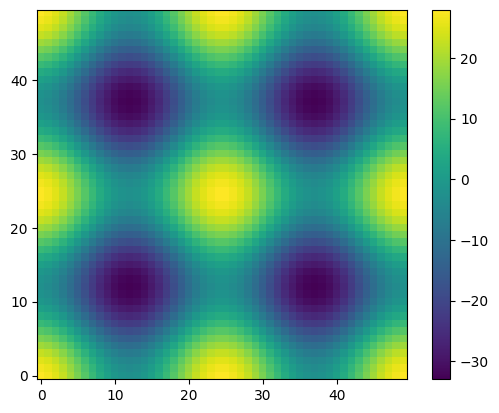

In [515]:
p_exact = p(XXp,YYp,1)
rhs = 4*p_exact.reshape(-1)
p_vec = spsolve(lap2d(N,1),rhs)
p_num = p_vec.reshape((N,N))

plt.imshow(p_num,origin='lower')
plt.colorbar()

In [516]:
def prediction_v(u_exp,v_exp,dt,N,h,nu):
    lap = lap2d(N,h)
    ax = 0.5*(u_exp[0:-1,:] + u_exp[1:,:])
    #print('ax',ax[0,:])
    ay = 0.5*(v_exp[0:,:-1] + np.roll(v_exp[0:,:-1], 1, axis=0))
    #print('umat1',ay[0,1]*dt/(2*h))
    #print('umat2',-ay[0,0]*dt/(2*h))
    #print('umat3',ax[0,0]*dt/(2*h))
    #print('umat4',-ax[-1,0]*dt/(2*h))

    u_adv = adv2d(ay,ax,N,h)
    #print('ADVU',u_adv[0,:])
    v_adv = adv2d(ax.T,ay.T,N,h)

    u_mat = identity(N*N) + dt*nu*lap + dt*u_adv
    #print('u_mat',u_mat[0,:])
    v_mat = identity(N*N) + dt*nu*lap + dt*v_adv

    u_rhs = u_exp[:-1,:].reshape(-1)
    v_rhs = (v_exp[:,:-1].T).reshape(-1)

    u_vec = spsolve(u_mat, u_rhs)
    v_vec = spsolve(v_mat, v_rhs)

    U = u_vec.reshape((N,N))
    V = v_vec.reshape((N,N)).T
    
    U = np.vstack([U, U[0,:]])
    V = np.hstack([V, V[:,[0]]])
    
    return U,V

def pression(u,v,dt,h,N):
    div_U = div(u,v,h)
    lap = lap2d(N,h)
    rhs = -div_U/dt
    rhs = rhs.reshape(-1)


    p_vec = spsolve(lap,rhs)

    P = p_vec.reshape((N,N))

    return P

def correction_vitesse(u,v,p,dt,h):
    grad_pi, grad_pj = grad(p,h)
    U = u - dt*grad_pi
    V = v - dt*grad_pj

    return U,V



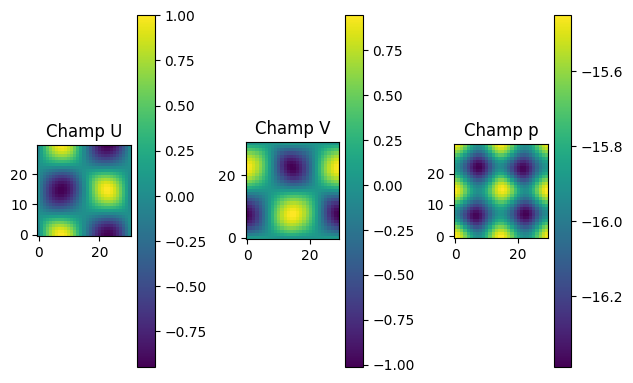

In [517]:
L = 2*np.pi
nu = 0.01
N = 30
h=L/N
Nt = 200
T = 1
dt = T/Nt
x = np.linspace(0,L,N+1)
y = np.linspace(0,L,N+1)
xm = 0.5*(x[1:] + x[:-1])
ym = xm

XXu, YYu = np.meshgrid(x,ym,indexing='ij')
XXv, YYv = np.meshgrid(xm,y,indexing='ij')
XXp, YYp = np.meshgrid(xm,ym,indexing='ij')

u_init = np.sin(XXu)*np.cos(YYu)
v_init = -np.cos(XXv)*np.sin(YYv)


#print(u_init[10,:])

u = u_init
v = v_init
for i in range(Nt):
    u1, v1 = prediction_v(u,v,dt,N,h,nu)
    #print('u1',u1[0,:])
    #print('v1',v1[0,:])
    p = pression(u1, v1, dt, h, N)
    u, v = correction_vitesse(u1, v1, p, dt, h)

U, V = u, v
#print(dt)
plt.subplot(1, 3, 1)
plt.imshow(U.T, origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Champ U")

plt.subplot(1, 3, 2)
plt.imshow(V.T, origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Champ V")

plt.subplot(1, 3, 3)
plt.imshow(p.T, origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Champ p")

plt.tight_layout()